In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import cftime
from pylab import *
from matplotlib.ticker import  MultipleLocator
from matplotlib.ticker import  FormatStrFormatter
import glob 

In [2]:
names = glob.glob(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\obspack_naq_ct.r3\naq.o\*aircraft*')
names_2 = glob.glob(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\obspack_naq_ct.r3\ct.o\*aircraft*')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats  # 用于计算置信区间

In [4]:

import os  # 新增模块导入
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from scipy import stats  # 确保已导入stats模块
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
import numpy as np
from matplotlib.gridspec import GridSpec


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
import numpy as np
from matplotlib.gridspec import GridSpec

In [25]:
names_re = [
 'D:\\论文撰写\\NAQPMS多源模式验证与加拿大模拟\\数据作图\\obspack_naq_ct.r3\\naq.o\\co2_iagos-caribic_aircraft-insitu_457_allvalid.csv', 
 'D:\\论文撰写\\NAQPMS多源模式验证与加拿大模拟\\数据作图\\obspack_naq_ct.r3\\naq.o\\co2_tom_aircraft-insitu_1_allvalid.csv',
 'D:\\论文撰写\\NAQPMS多源模式验证与加拿大模拟\\数据作图\\obspack_naq_ct.r3\\naq.o\\co2_hip_aircraft-insitu_59_allvalid.csv',
 'D:\\论文撰写\\NAQPMS多源模式验证与加拿大模拟\\数据作图\\obspack_naq_ct.r3\\naq.o\\co2_act_aircraft-insitu_428_allvalid-b200.csv',
  'D:\\论文撰写\\NAQPMS多源模式验证与加拿大模拟\\数据作图\\obspack_naq_ct.r3\\naq.o\\co2_gsfc_aircraft-insitu_430_allvalid.csv',
 'D:\\论文撰写\\NAQPMS多源模式验证与加拿大模拟\\数据作图\\obspack_naq_ct.r3\\naq.o\\co2_above_aircraft-pfp_1_allvalid.csv',
 'D:\\论文撰写\\NAQPMS多源模式验证与加拿大模拟\\数据作图\\obspack_naq_ct.r3\\naq.o\\co2_bne_aircraft-pfp_1_allvalid.csv',
 'D:\\论文撰写\\NAQPMS多源模式验证与加拿大模拟\\数据作图\\obspack_naq_ct.r3\\naq.o\\co2_rta_aircraft-pfp_1_allvalid.csv',
 ]

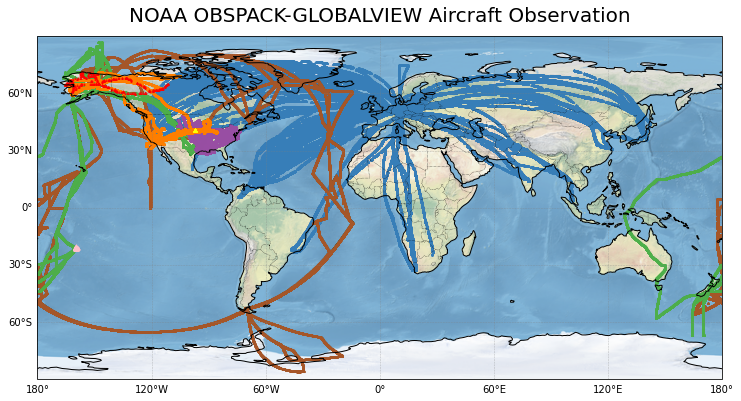

In [38]:
# === 定义画布和布局 ===
fig = plt.figure(figsize=(18, 8))  # 整体高度从10调整为8，让左右子图都更矮

# 创建GridSpec布局：
# - 使用3行1列的垂直布局，左侧子图占中间1行，右侧占全部3行
# - 通过height_ratios控制左侧子图的垂直位置
gs = GridSpec(3, 2, 
                width_ratios=[1, 3],      # 左右宽度比例1:3
                height_ratios=[1,6,1],    # 控制左侧子图垂直居中且高度压缩
                wspace=0.2, hspace=0.1)   # 控制子图间距



# === 右侧子图：地图 ===
ax2 = fig.add_subplot(gs[:, 1], projection=ccrs.PlateCarree())  # 右侧占满3行高度
ax2.set_title("NOAA OBSPACK-GLOBALVIEW Aircraft Observation", fontsize=20, pad=15)
ax2.stock_img()
ax2.coastlines(resolution='110m', linewidth=1)
ax2.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# 添加网格线
gl = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

missing_files = []

colors = [
    "#377eb8",  # 鲜蓝
    "#a65628",  # 棕色
    "#4daf4a",  # 鲜绿
    "#984ea3",  # 紫色
    "#ff7f00",  # 橙色
    'red',
]

for idx, iname in enumerate(names_re[:6]):
    try:
        # 读取第一个文件
        df = pd.read_csv(iname)
        
        # 使用更安全的路径拼接方式
        ct_dir = r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\obspack_naq_ct.r3\ct.o\\'
        base_name = os.path.basename(iname)  # 自动提取文件名
        ct_path = os.path.join(ct_dir, base_name)
        
        # 尝试读取第二个文件
        df2 = pd.read_csv(ct_path)
    
    except FileNotFoundError as e:
        print(f"文件缺失跳过: {e.filename}")
        missing_files.append(e.filename)  # 记录缺失文件
        continue  # 跳过当前文件的后续处理
    
    altitude_obs = df['sta_altitude_out']/1000.
    altitude_obs2 = df2['sta_altitude_out']/1000.
    conc_obs = df['sta_value_out']
    #conc_obs_ct = df2['sta_value_out']
    conc_naq = df['naq_value_out']
    conc_ct = df2['ct_value_out']
    
    lat_dem = np.array(df['sta_lat_out'].values)
    lon_dem = np.array(df['sta_lon_out'].values)

    
    max_altitude = max(altitude_obs.max(), altitude_obs2.max())
    boundaries = np.linspace(0, max_altitude, 12)
    
    df['altitude_bin'] = np.digitize(altitude_obs, boundaries) - 1
    df2['altitude_bin'] = np.digitize(altitude_obs2, boundaries) - 1
        

    ax2.scatter(
        lon_dem,  # 经度
        lat_dem,   # 纬度
        color=colors[idx],                # 红色
        marker='^',                 # 三角形
        s=2,                       # 标记大小
        transform=ccrs.PlateCarree(),
        alpha=0.7,  # 坐标系
        label="Station Locations"   # 图例标签
    )


colors = [
    "yellow",  
    'pink',
]
for idx, iname in enumerate(names_re[6:]):
    try:
        # 读取第一个文件
        df = pd.read_csv(iname)
        
        # 使用更安全的路径拼接方式
        ct_dir = r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\obspack_naq_ct.r3\ct.o\\'
        base_name = os.path.basename(iname)  # 自动提取文件名
        ct_path = os.path.join(ct_dir, base_name)
        
        # 尝试读取第二个文件
        df2 = pd.read_csv(ct_path)
    
    except FileNotFoundError as e:
        print(f"文件缺失跳过: {e.filename}")
        missing_files.append(e.filename)  # 记录缺失文件
        continue  # 跳过当前文件的后续处理
    
    altitude_obs = df['sta_altitude_out']/1000.
    altitude_obs2 = df2['sta_altitude_out']/1000.
    conc_obs = df['sta_value_out']
    #conc_obs_ct = df2['sta_value_out']
    conc_naq = df['naq_value_out']
    conc_ct = df2['ct_value_out']
    
    lat_dem = np.array(df['sta_lat_out'].values)
    lon_dem = np.array(df['sta_lon_out'].values)

    
    max_altitude = max(altitude_obs.max(), altitude_obs2.max())
    boundaries = np.linspace(0, max_altitude, 12)
    
    df['altitude_bin'] = np.digitize(altitude_obs, boundaries) - 1
    df2['altitude_bin'] = np.digitize(altitude_obs2, boundaries) - 1
        

    ax2.scatter(
        lon_dem,  # 经度
        lat_dem,   # 纬度
        color=colors[idx],                # 红色
        marker='^',                 # 三角形
        s=10,                       # 标记大小
        transform=ccrs.PlateCarree(),
        alpha=0.7,  # 坐标系
        label="Station Locations"   # 图例标签
    )

 

plt.rcParams['savefig.dpi'] = 500
plt.savefig(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\obspack_naq_ct.r3\{}.png'.format(iname[56:-4]),bbox_inches='tight')
#plt.show()
   